In [1]:
import json
with open("results_dict_2.json", "r") as f:
    results_dict = json.load(f)
    
with open("results_marcowitz.json", "r") as f:
    results_dict_marcowitz = json.load(f)

In [2]:
pesos_carteiras = {}
for key in results_dict.keys():
    pesos_carteiras[key.split(" a ")[1]] = results_dict[key]["tickers_weights"]
    
pesos_carteiras_marcowitz = {}
for key in results_dict_marcowitz.keys():
    pesos_carteiras_marcowitz[key.split(" a ")[1]] = results_dict_marcowitz[key]

    

In [3]:
chaves = list(pesos_carteiras.keys())
chave_no_indice = chaves[0]

chaves_marcowitz = list(pesos_carteiras_marcowitz.keys())
chave_no_indice_marcowitz = chaves_marcowitz[0]




In [4]:
import yfinance as yf
import logging
import pandas as pd
import datetime
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

chaves = list(pesos_carteiras.keys())

precos_carteira = {}

for key, value in enumerate(chaves):
    acoes = list(pesos_carteiras[value].keys())
    acoes_sa = [acao if acao.endswith(".SA") else f"{acao}.SA"  for acao in acoes]
    start = value
    if value == chaves[-1]:
        end = datetime.datetime.now().strftime("%Y-%m-%d")
    else:    
        end = chaves[key+1]
    logger.info(f"Baixando dados de {start} a {end}, para as acoes {acoes_sa}")
    precos_carteira[value] = yf.download(acoes_sa, start=str(start), end= str(end))["Close"]
    

chaves_marcowitz = list(pesos_carteiras_marcowitz.keys())

precos_carteira_marcowitz = {}

for key, value in enumerate(chaves_marcowitz):
    acoes = list(pesos_carteiras_marcowitz[value].keys())
    acoes_sa = [acao if acao.endswith(".SA") else f"{acao}.SA"  for acao in acoes]
    start = value
    if value == chaves_marcowitz[-1]:
        end = datetime.datetime.now().strftime("%Y-%m-%d")
    else:    
        end = chaves_marcowitz[key+1]
    logger.info(f"Baixando dados de {start} a {end}, para as acoes {acoes_sa}")
    precos_carteira_marcowitz[value] = yf.download(acoes_sa, start=str(start), end= str(end))["Close"]

INFO:__main__:Baixando dados de 2016-12-31 a 2017-03-31, para as acoes ['CSUD3.SA', 'CGAS3.SA', 'MDIA3.SA', 'FLRY3.SA', 'VIVT3.SA', 'ABEV3.SA', 'ITUB4.SA']
C:\Users\jefer\AppData\Local\Temp\ipykernel_42820\3054855618.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  precos_carteira[value] = yf.download(acoes_sa, start=str(start), end= str(end))["Close"]
[*********************100%***********************]  7 of 7 completed
INFO:__main__:Baixando dados de 2017-03-31 a 2017-06-30, para as acoes ['ABEV3.SA', 'LREN3.SA', 'BBDC4.SA', 'ITUB4.SA', 'EGIE3.SA', 'CSUD3.SA', 'PSSA3.SA']
C:\Users\jefer\AppData\Local\Temp\ipykernel_42820\3054855618.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  precos_carteira[value] = yf.download(acoes_sa, start=str(start), end= str(end))["Close"]
[*********************100%***********************]  7 of 7 completed
INFO:__main__:Baixando dados de 2017-06-30 a 2017-09-30, para as acoes ['ABE

In [5]:
def daily_returns(prices):
    return prices.pct_change()[1:]

def cumulative_returns(df):
    return (df.apply(daily_returns)+1).cumprod()

def retorno_carteira_monetario(df, pesos, valor_investido):
    pesos_frac = [p/100 for p in pesos]
    valor_investido_carteira = [valor_investido * peso for peso in pesos_frac]
    retorno_carteira = (cumulative_returns(df) * valor_investido_carteira).sum(axis=1)
    return retorno_carteira

def retorno_percentual_acao_individual(pesos_carteiras, precos_carteira):
    """pesos_frac = [p/100 for p in pesos_carteiras[chaves[keys]].values()]
    valor_investido_carteira = [1000 * peso for peso in pesos_frac]
    retorno_carteira = (cumulative_returns(precos_carteira[chaves[keys]]) * valor_investido_carteira)"""
    
    
    pesos_frac = [p/100 for p in pesos_carteiras.values()]
    valor_investido_carteira = [1000 * peso for peso in pesos_frac]
    
    # Usar diretamente precos_df (já é o DataFrame correto)
    retorno_carteira = cumulative_returns(precos_carteira) * valor_investido_carteira
    
    retorno_percentual = retorno_carteira.apply(
        lambda x: (x.iloc[-1] - x.iloc[0]) / x.iloc[0] * 100
    )
    return retorno_percentual

In [6]:
def verificando_valores_nulos(keys, pesos_carteiras, precos_carteira):
    dict_keys = pesos_carteiras[chaves[keys]].copy()
    null = precos_carteira[chaves[keys]].isna().any()
    list_name_null = precos_carteira[chaves[keys]].loc[:,null].columns.to_list()
    
    dict_keys = {
        (key if key.endswith(".SA") else f"{key}.SA"): value 
        for key, value in pesos_carteiras[chaves[keys]].items()
    }
    valor_do_tic_null = 0
    for tic in list_name_null:
        valor_do_tic_null += dict_keys[tic]
        dict_keys.pop(tic)  # Remover cada ticker individualmente
    
    quantidade_sobrou = len(dict_keys)
    
    if quantidade_sobrou == 0:
        return {}  # Evitar divisão por zero
    
    valor_para_cada_tic = valor_do_tic_null / quantidade_sobrou
    
    dict_com_novos_valores = {}
    for key, value in dict_keys.items():
        dict_com_novos_valores[key] = value + valor_para_cada_tic
    
    return dict_com_novos_valores

In [7]:
from IPython.display import display, Markdown
carteira = pd.DataFrame()
carteira_marcowitz = pd.DataFrame()
for key, value in enumerate(chaves):
    
    print("*" * 40)
    
    display(Markdown(f"**O retorno da carteira para o período: {value}**"))
    
    ## Pesos selecionados pelo modelo
    pesos_sem_erro = verificando_valores_nulos(key, pesos_carteiras, precos_carteira)
    
    precos_sem_nan = precos_carteira[chaves[key]].dropna(axis=1)
    
    carteira_percentual_acoes = retorno_percentual_acao_individual(pesos_sem_erro, precos_sem_nan)
    
    # carteira de markowits
    try:
        pesos_sem_erro_markowitz = verificando_valores_nulos(key, pesos_carteiras_marcowitz, precos_carteira_marcowitz)
        pesos_sem_erro_markowitz = {key_: value*100 for key_, value in pesos_sem_erro_markowitz.items()}
    
        precos_sem_nan_markwitz = precos_carteira_marcowitz[chaves[key]].dropna(axis=1)
    
        carteira_percentual_acoes_marcowitz = retorno_percentual_acao_individual(pesos_sem_erro_markowitz, precos_sem_nan_markwitz)
    except Exception as e:  
        logger.info(f"Erro ao obter:{e}")
    
    data = pd.DataFrame(pesos_sem_erro, index=["Pesos"]).T
    data_markwitz = pd.DataFrame(pesos_sem_erro_markowitz, index=["Pesos"]).T
    
    if not carteira_percentual_acoes.empty:
        data['retornos em %'] = pd.DataFrame(carteira_percentual_acoes)
        data_markwitz['retornos markwitz em %'] = pd.DataFrame(carteira_percentual_acoes_marcowitz)
    else:
        print("Nenhum dado foi obtido!")
        
    display(data.T.style.set_caption("Pesos").background_gradient(cmap="Blues"))
    
    display(data_markwitz.T.style.set_caption("Pesos").background_gradient(cmap="Blues"))

    if key == 0:
        valor_carteira = retorno_carteira_monetario(precos_sem_nan, pesos_sem_erro.values(), 1000)
        
        valor_carteira_markwitz = retorno_carteira_monetario(precos_sem_nan_markwitz, pesos_sem_erro_markowitz.values(), 1000)

        
    else:   
        valor_carteira = retorno_carteira_monetario(precos_sem_nan, pesos_sem_erro.values(), valor_atual_carteira)
        
        valor_carteira_markwitz = retorno_carteira_monetario(precos_sem_nan_markwitz, pesos_sem_erro_markowitz.values(), valor_atual_carteira_markwitz)
    
    carteira = pd.concat([carteira, valor_carteira])
    carteira_marcowitz = pd.concat([carteira_marcowitz, valor_carteira_markwitz])
    
    try:
        valor_atual_carteira = int(valor_carteira.iloc[-1])
        valor_atual_carteira_markwitz = int(valor_carteira_markwitz.iloc[-1])
    
    except:
        pass
    
    
     
    

****************************************


**O retorno da carteira para o período: 2016-12-31**

,CSUD3.SA,CGAS3.SA,MDIA3.SA,FLRY3.SA,VIVT3.SA,ABEV3.SA,ITUB4.SA
Pesos,16.665139,16.665139,16.665139,16.665139,12.503438,13.337611,7.498396
retornos em %,98.591513,6.209608,7.899021,23.443014,7.174993,10.240695,12.482801


,ABEV3.SA,CGAS3.SA,CSUD3.SA,FLRY3.SA,ITUB4.SA,MDIA3.SA,VIVT3.SA
Pesos,19.834362,14.594217,6.384908,10.411643,14.569841,4.967669,29.237360
retornos markwitz em %,10.240713,6.209598,98.591585,23.443032,12.482857,7.899056,7.174953


****************************************


...

****************************************


**O retorno da carteira para o período: 2025-12-12**

C:\Users\jefer\AppData\Local\Temp\ipykernel_42820\1529076990.py:26: RuntimeWarning: invalid value encountered in scalar divide
  lambda x: (x.iloc[-1] - x.iloc[0]) / x.iloc[0] * 100
INFO:__main__:Erro ao obter:'2025-12-12'


,LREN3.SA,WEGE3.SA,VIVT3.SA,CGAS3.SA,ITUB4.SA,ABEV3.SA,GGBR4.SA,FIQE3.SA,VALE3.SA
Pesos,20.116677,16.757192,13.407765,13.407765,13.407765,10.058338,7.815329,5.029169,0.000000
retornos em %,-3.731859,nan,-2.508110,0.083325,-2.576811,-0.840335,1.374564,-1.217394,0.376651


,ABEV3.SA,CSUD3.SA,ELET3.SA,FIQE3.SA,ITUB4.SA,VIVT3.SA,WEGE3.SA
Pesos,20.177118,10.625782,16.375782,10.881618,10.824120,12.978626,18.136954
retornos markwitz em %,8.040372,3.319300,67.639541,56.325116,13.392564,7.011369,19.627858


In [8]:
start_bove = chaves[0]
end_bove = chaves[-1]

In [9]:
start_bove = chaves[0]
end_bove = chaves[-1]
ibov = yf.download("^BVSP", start= start_bove, end=end_bove)["Close"]

ibov_retornos = cumulative_returns(ibov) *1000

C:\Users\jefer\AppData\Local\Temp\ipykernel_42820\2161183779.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ibov = yf.download("^BVSP", start= start_bove, end=end_bove)["Close"]
[*********************100%***********************]  1 of 1 completed


In [10]:
import pandas as pd
from bcb import sgs

def get_selic_multiplos_periodos(data_inicio, data_fim, anos_por_janela=5):
    """
    Busca dados da SELIC em janelas de X anos para contornar limitação da API
    """
    inicio = pd.to_datetime(data_inicio)
    fim = pd.to_datetime(data_fim)
    
    # Lista para armazenar os dataframes
    dados_completos = []
    
    # Criar janelas
    current_start = inicio
    
    while current_start < fim:
        current_end = min(current_start + pd.DateOffset(years=anos_por_janela), fim)
        
        print(f"Buscando dados de {current_start.date()} até {current_end.date()}...")
        
        try:
            # Fazer requisição para a janela atual
            dados_janela = sgs.get({'selic': 11, 
                                    #'cdi' :12
                                    }, 
                                   start=current_start.strftime('%Y-%m-%d'),
                                   end=current_end.strftime('%Y-%m-%d'))
            
            dados_completos.append(dados_janela)
            print(f"  ✓ {len(dados_janela)} registros obtidos")
            
        except Exception as e:
            print(f"  ✗ Erro ao buscar dados: {e}")

        current_start = current_end + pd.Timedelta(days=1)

    if dados_completos:
        selic_completo = pd.concat(dados_completos)
        selic_completo = selic_completo[~selic_completo.index.duplicated(keep='first')]
        selic_completo = selic_completo.sort_index()
        
        print(f"\n✓ Total de registros: {len(selic_completo)}")
        print(f"✓ Período: {selic_completo.index.min().date()} até {selic_completo.index.max().date()}")
        
        return selic_completo
    else:
        print("Nenhum dado foi obtido!")
        return None

# Usar a função
selic = get_selic_multiplos_periodos(start_bove, end_bove)


Buscando dados de 2016-12-31 até 2021-12-31...
  ✓ 1254 registros obtidos
Buscando dados de 2022-01-01 até 2025-12-12...
  ✓ 993 registros obtidos

✓ Total de registros: 2247
✓ Período: 2017-01-02 até 2025-12-12


In [11]:
selic_acumulada =  ((selic/100 + 1).cumprod())*1000
selic_acumulada

,selic
Date,
2017-01-02,1000.507880
2017-01-03,1001.016018
2017-01-04,1001.524414
2017-01-05,1002.033068
2017-01-06,1002.541981
...,...
2025-12-08,2123.608498
2025-12-09,2124.779265
2025-12-10,2125.950677


In [17]:
retorno_acumulado_monetario = pd.concat([selic_acumulada, ibov_retornos, carteira], axis=1).rename(columns={0: "Carteira", "selic": "SELIC", "^BVSP": "IBOV",})
carteira_marcowitz = carteira_marcowitz[~carteira_marcowitz.index.duplicated(keep='last')]
retorno_acumulado_monetario['Markowitz'] = carteira_marcowitz



In [21]:
retorno_acumulado_monetario.dropna()

,SELIC,IBOV,Carteira,Markowitz
2017-01-03,1001.016018,1037.339106,1022.541150,1022.768719
2017-01-04,1001.524414,1033.563242,1036.459162,1028.529430
2017-01-05,1002.033068,1041.651983,1050.173288,1028.103777
2017-01-06,1002.541981,1034.838645,1046.615474,1028.489732
2017-01-09,1003.051152,1035.426001,1057.094786,1034.509374
...,...,...,...,...
2025-12-05,2122.438377,2640.906879,3429.684384,5444.636659
2025-12-08,2123.608498,2654.634245,3462.831024,5502.196104
2025-12-09,2124.779265,2651.177231,3479.260008,5521.113180
2025-12-10,2125.950677,2669.536324,3468.858265,5520.084821


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===============================================================
# MÉTRICAS
# ===============================================================

def daily_returns(prices):
    return prices.pct_change()[1:]

def annualized_volatility(daily_ret, trading_days=252):
    return daily_ret.std() * np.sqrt(trading_days)

def annualized_mean_return(daily_ret, trading_days=252):
    return daily_ret.mean() * trading_days

def cagr(prices):
    days = (prices.index[-1] - prices.index[0]).days
    years = days / 365.25
    return (prices.iloc[-1] / prices.iloc[0])**(1/years) - 1 if years > 0 else np.nan

def max_drawdown(prices):
    cum_max = prices.cummax()
    drawdowns = (prices - cum_max) / cum_max
    return drawdowns.min()

def avg_drawdown(prices):
    dd = (prices / prices.cummax()) - 1
    negatives = dd < 0
    groups = (negatives.astype(int).diff() != 0).cumsum()
    avg_dds = []
    for _, grp in dd.groupby(groups):
        if (grp < 0).any():
            avg_dds.append(grp.min())
    return np.mean(avg_dds) if avg_dds else 0.0

def calmar_ratio(prices):
    ann_ret = cagr(prices)
    mdd = max_drawdown(prices)
    return ann_ret / abs(mdd) if mdd != 0 else np.nan

def sortino_ratio(daily_ret, required_return=0.0, trading_days=252):
    rr_daily = (1 + required_return)**(1/trading_days) - 1
    downside = daily_ret[daily_ret < rr_daily] - rr_daily
    if downside.size == 0:
        return np.nan
    dd = np.sqrt((downside**2).mean()) * np.sqrt(trading_days)
    ann_ret = annualized_mean_return(daily_ret, trading_days)
    return (ann_ret - required_return) / dd if dd != 0 else np.nan

def compute_metrics(price_df):
    metrics = {}
    for col in price_df.columns:
        p = price_df[col].dropna()
        dr = daily_returns(p)
        metrics[col] = {
            "ann_vol": annualized_volatility(dr),
            "ann_mean_ret": annualized_mean_return(dr),
            "cagr": cagr(p),
            "max_drawdown": max_drawdown(p),
            "avg_drawdown": avg_drawdown(p),
            "calmar": calmar_ratio(p),
            "sortino": sortino_ratio(dr)
        }
    return pd.DataFrame(metrics).T

In [19]:
compute_metrics(retorno_acumulado_monetario).style.set_caption("Métricas das Carteiras").background_gradient(cmap="Blues")

,ann_vol,ann_mean_ret,cagr,max_drawdown,avg_drawdown,calmar,sortino
SELIC,0.002377,0.084707,0.088079,0.000000,0.000000,nan,nan
IBOV,0.229450,0.133955,0.111661,-0.468158,-0.036645,0.238512,0.554214
Carteira,0.241548,0.169678,0.146197,-0.514521,-0.052826,0.284142,0.646639
Markowitz,0.233201,0.221562,0.208727,-0.482303,-0.031865,0.432772,0.957521


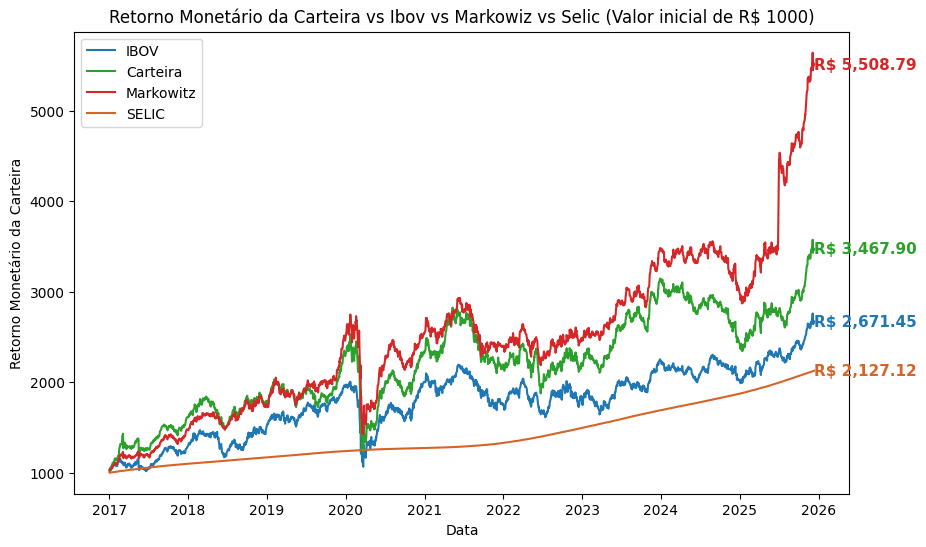

In [23]:
from matplotlib import pyplot as plt
plt.figure(figsize=(10, 6))
cores = {'IBOV': '#1f77b4', 'Carteira': '#2ca02c', 'Markowitz': '#d62728', 'SELIC': "#d66427"}
retorno_acumulado_monetario = retorno_acumulado_monetario.dropna()
for nome in ['IBOV', 
             'Carteira', 
             'Markowitz', 
             'SELIC']:
    plt.plot(
            retorno_acumulado_monetario.index,
            retorno_acumulado_monetario[nome],
                label=nome,
                color=cores[nome]
            )
    ultimo_x = retorno_acumulado_monetario[nome].index[-1]
    ultimo_y = retorno_acumulado_monetario[nome].iloc[-1]
    plt.text(
                ultimo_x, ultimo_y,
                f'R$ {ultimo_y:,.2f}',
                color=cores[nome],
                fontsize=11,
                va='center',
                fontweight='bold'
            )

plt.legend()
plt.xlabel("Data")
plt.ylabel("Retorno Monetário da Carteira")
plt.title(f"Retorno Monetário da Carteira vs Ibov vs Markowiz vs Selic (Valor inicial de R$ {1000})")
plt.show()

In [ ]:
pesos_carteiras[chaves[0]], pesos_carteiras_marcowitz[chaves[0]]

({'CSUD3.SA': 16.6651388761573,
  'CGAS3.SA': 16.6651388761573,
  'MDIA3.SA': 16.6651388761573,
  'FLRY3.SA': 16.6651388761573,
  'VIVT3.SA': 12.503437528646073,
  'ABEV3.SA': 13.337611146759556,
  'ITUB4.SA': 7.498395819965166},
 {'ABEV3.SA': 0.19834362157689311,
  'CGAS3.SA': 0.1459421731698627,
  'CSUD3.SA': 0.06384908331126404,
  'FLRY3.SA': 0.10411642898849506,
  'ITUB4.SA': 0.1456984081830365,
  'MDIA3.SA': 0.049676687588103764,
  'VIVT3.SA': 0.2923735971823449})